In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### ----------------------------------------------------------
## Load Data
##### ----------------------------------------------------------

In [2]:
df = pd.read_csv('../data/netflix_titles.csv')

# --------------------------------
## Data Cleaning
# --------------------------------

In [3]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# Date processing

In [4]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [5]:
df['description'] = df['description'].fillna('')

# -------------------------
## EDA
# -------------------------

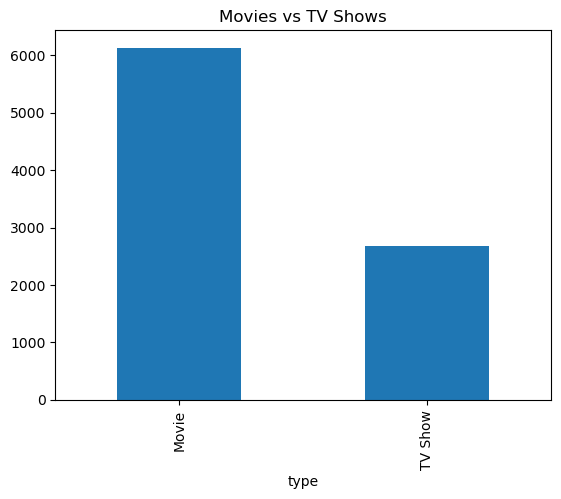

In [6]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.savefig('../images/type_distribution.png')
plt.show()

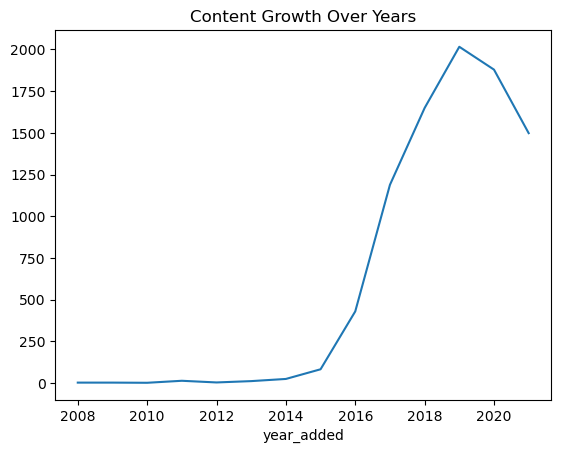

In [7]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.savefig('../images/growth.png')
plt.show()

# -------------------------
## NLP - TF-IDF
# -------------------------

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

# -------------------------
## Similarity
# -------------------------

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# -------------------------
## Index Mapping
# -------------------------

In [10]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()


# -------------------------
## Recommendation Function
# -------------------------

In [11]:
def recommend(title, top_n=10):
    if title not in indices:
        return "Movie not found"
    idx = indices[title]
    
    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return df['title'].iloc[movie_indices]

# -------------------------
## Example
# -------------------------

In [12]:
recommend("Narcos", 5)

7463                          Miss Dynamite
6673                            El Cartel 2
2921                         Narcos: Mexico
4750                               El Chapo
310     Cocaine Cowboys: The Kings of Miami
Name: title, dtype: object